Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



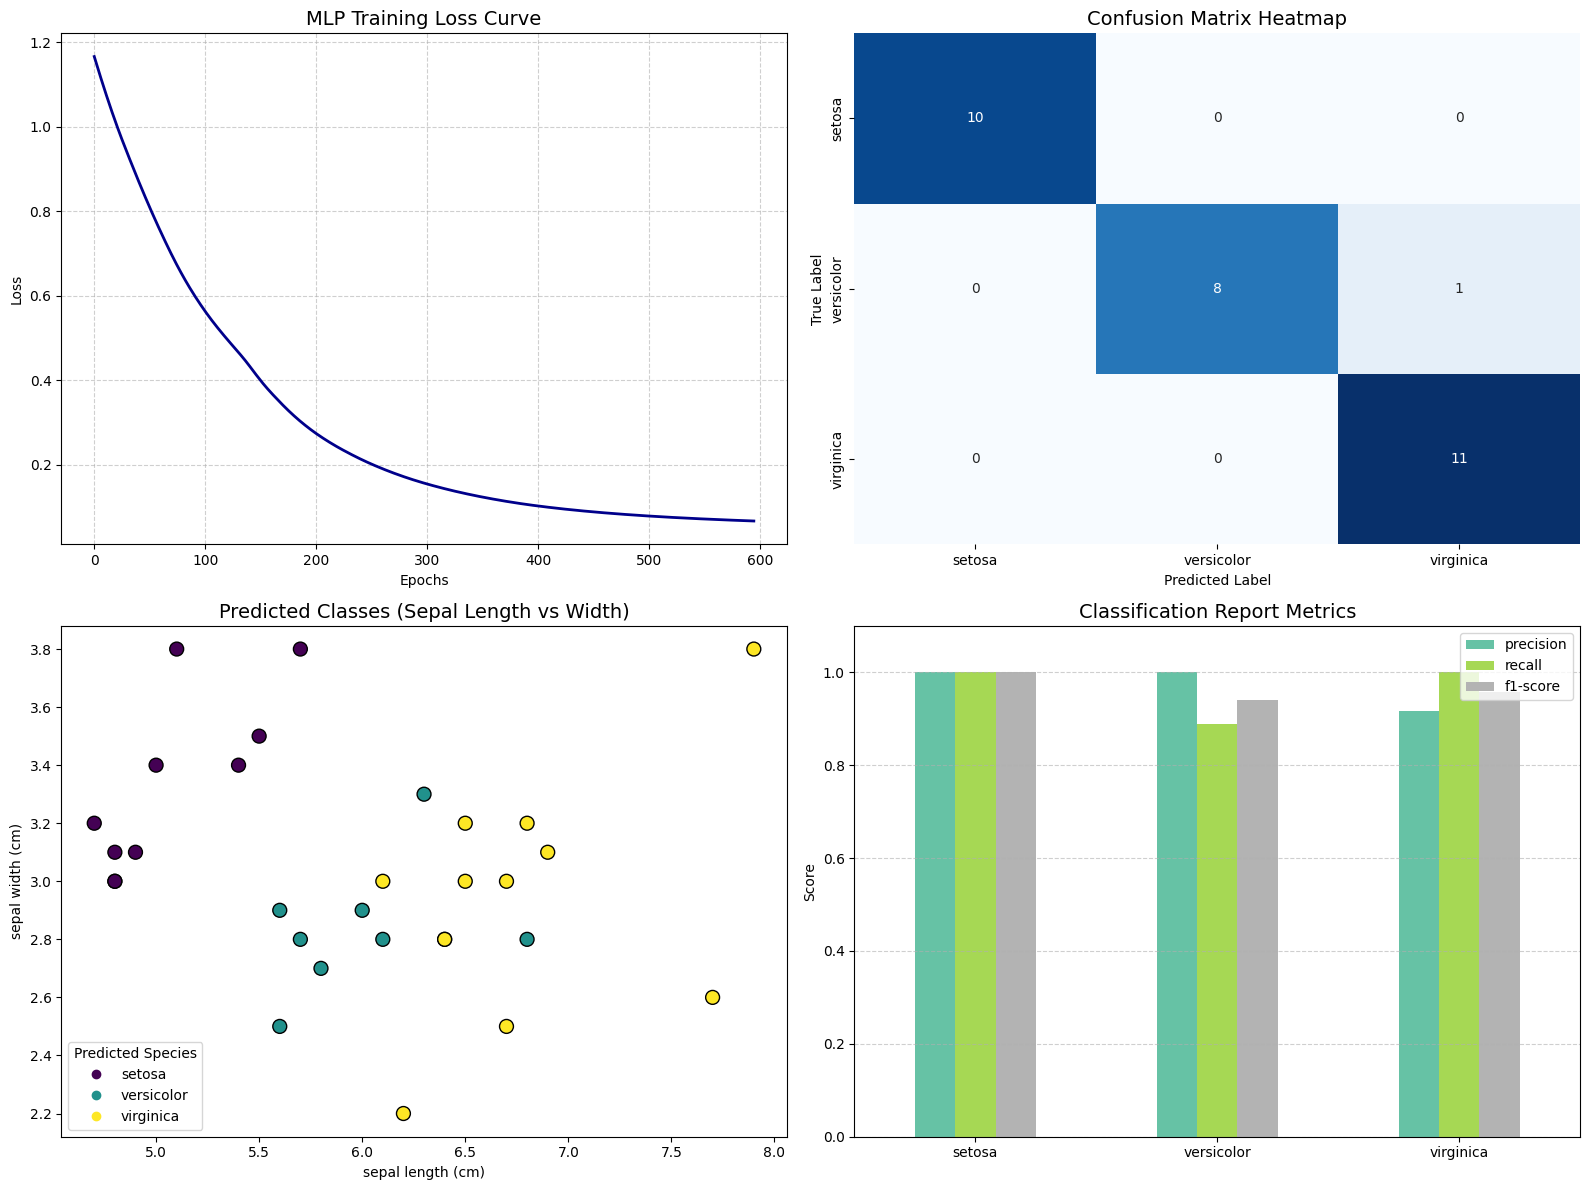

In [ ]:
# ============================================================
# Assignment 2: Iris Dataset Classification using MLP
# Name: Raj Kanade | Roll No: 26 | PRN: 12413760 | Batch: B3
# ============================================================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(10,10), activation='relu', solver='adam', max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loss Curve
axes[0, 0].plot(mlp.loss_curve_, color='darkblue', lw=2)
axes[0, 0].set_title('MLP Training Loss Curve', fontsize=14)
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=iris.target_names, yticklabels=iris.target_names, cbar=False)
axes[0, 1].set_title('Confusion Matrix Heatmap', fontsize=14)
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# 3. Scatter Plot of Test Predictions (Sepal Length vs Sepal Width)
X_test_orig = scaler.inverse_transform(X_test)
scatter = axes[1, 0].scatter(X_test_orig[:, 0], X_test_orig[:, 1], c=y_pred, cmap='viridis', s=100, edgecolors='k')
axes[1, 0].set_title('Predicted Classes (Sepal Length vs Width)', fontsize=14)
axes[1, 0].set_xlabel(iris.feature_names[0])
axes[1, 0].set_ylabel(iris.feature_names[1])
handles, _ = scatter.legend_elements()
axes[1, 0].legend(handles, iris.target_names, title="Predicted Species")

# 4. Classification Report Metrics Bar Chart
report = classification_report(y_test, y_pred, target_names=iris.target_names, output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :3].T
df_report.plot(kind='bar', ax=axes[1, 1], colormap='Set2')
axes[1, 1].set_title('Classification Report Metrics', fontsize=14)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_xticklabels(iris.target_names, rotation=0)
axes[1, 1].set_ylim(0, 1.1)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
